In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ruta local data en VS Code
df = pd.read_csv('C:/Documents/projects/Proyecto5_equipo4_regresion/data/raw/LifeExpectancyData_raw.csv')

print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [7]:
# PASO 1: Limpieza de nombres de columnas
# Usamos .strip() para eliminar los espacios invisibles que dan errores en este dataset
df.columns = df.columns.str.strip()

# Mostramos las primeras 5 filas para confirmar que todo se ve bien
# y listamos las columnas para estar 100% seguros de los nombres
print("Cleaned Column Names:")
print(df.columns.tolist())
df.head()

Cleaned Column Names:
['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


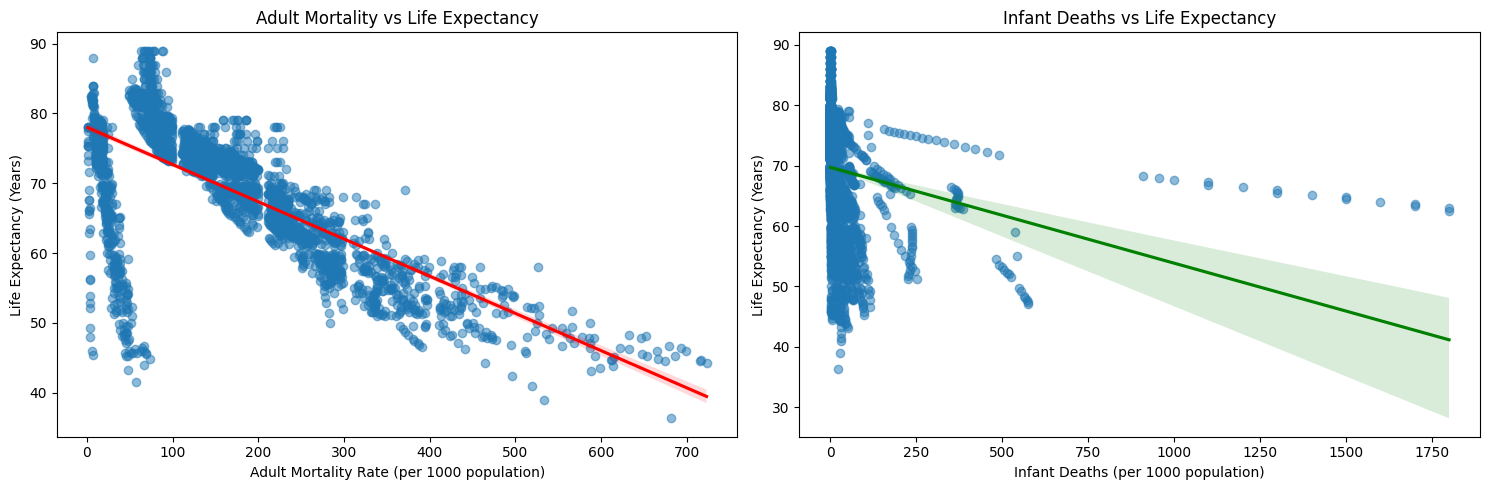

In [9]:
# PASO 2: Visualización de la relación entre mortalidad y esperanza de vida
# Creamos una figura con dos gráficos (uno para mortalidad adulta y otro para infantil)
plt.figure(figsize=(15, 5))

# Gráfico 1: Adult Mortality vs Life Expectancy
plt.subplot(1, 2, 1)
sns.regplot(data=df, x='Adult Mortality', y='Life expectancy', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Adult Mortality vs Life Expectancy')
plt.xlabel('Adult Mortality Rate (per 1000 population)')
plt.ylabel('Life Expectancy (Years)')

# Gráfico 2: Infant Deaths vs Life Expectancy
plt.subplot(1, 2, 2)
sns.regplot(data=df, x='infant deaths', y='Life expectancy', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'green'})
plt.title('Infant Deaths vs Life Expectancy')
plt.xlabel('Infant Deaths (per 1000 population)')
plt.ylabel('Life Expectancy (Years)')

plt.tight_layout()
plt.show()

In [10]:
# PASO 3: Cálculo de la correlación para la Pregunta 3
# Eliminamos filas con nulos en estas variables específicas para que el cálculo sea exacto
df_clean_mortalidad = df.dropna(subset=['Life expectancy', 'Adult Mortality', 'infant deaths'])

# Calculamos la correlación de Pearson
corr_adulta = df_clean_mortalidad['Adult Mortality'].corr(df_clean_mortalidad['Life expectancy'])
corr_infantil = df_clean_mortalidad['infant deaths'].corr(df_clean_mortalidad['Life expectancy'])

print(f"Correlation Adult Mortality vs Life expectancy: {corr_adulta:.2f}")
print(f"Correlation Infant Deaths vs Life expectancy: {corr_infantil:.2f}")

Correlation Adult Mortality vs Life expectancy: -0.70
Correlation Infant Deaths vs Life expectancy: -0.20


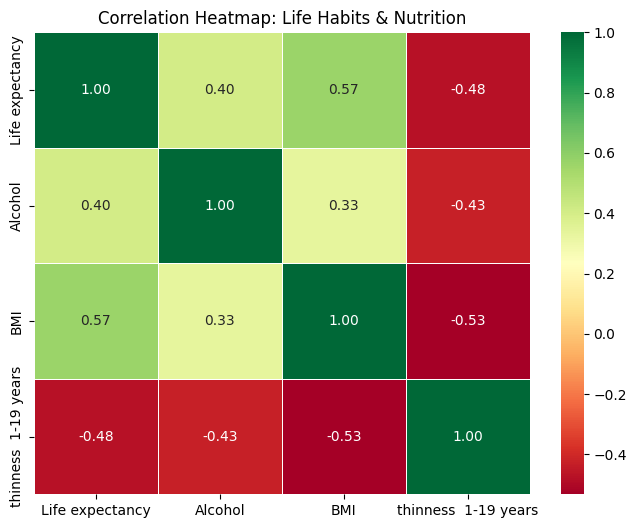

In [11]:
# PASO 4: Análisis de Correlación para Hábitos de Vida (Corregido)
# Seleccionamos las columnas fijándonos en los espacios exactos del dataset
# Nota: 'thinness  1-19 years' suele tener dos espacios en este CSV
columnas_habitos = ['Life expectancy', 'Alcohol', 'BMI', 'thinness  1-19 years']

# Intentamos calcular la matriz. Si vuelve a fallar, usamos una técnica de "búsqueda"
try:
    corr_habitos = df[columnas_habitos].corr()
except KeyError:
    # Si falla, buscamos las columnas que contengan estas palabras clave
    cols = [c for c in df.columns if any(word in c for word in ['Life', 'Alcohol', 'BMI', 'thinness 1-19'])]
    corr_habitos = df[cols].corr()

# Dibujamos el Mapa de Calor
plt.figure(figsize=(8, 6))
sns.heatmap(corr_habitos, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Life Habits & Nutrition')
plt.show()